# LArEventDisplay Example -- COPY ME

In [1]:
import h5py

# Paths to files
spine_path = '/home/bilal/LAr_evd/ndlar_flow/event_display/LAr_evd/packet-0050017-2024_07_09_00_04_33_CDT.SPINE.h5'
flow_path = '/home/bilal/LAr_evd/ndlar_flow/event_display/LAr_evd/packet-0050017-2024_07_09_00_04_33_CDT.FLOW.hdf5'

def inspect_h5_structure(file_path):
    """Prints the structure of an HDF5 file."""
    with h5py.File(file_path, 'r') as h5_file:
        def print_structure(name, obj):
            if isinstance(obj, h5py.Group):
                print(f"Group: {name}")
            elif isinstance(obj, h5py.Dataset):
                print(f"Dataset: {name} - Shape: {obj.shape} - Dtype: {obj.dtype}")

        h5_file.visititems(print_structure)

# Inspect both files
print("SPINE File Structure:")
inspect_h5_structure(spine_path)

print("\nFLOW File Structure:")
inspect_h5_structure(flow_path)

SPINE File Structure:
Dataset: depositions - Shape: (395579,) - Dtype: float32
Dataset: events - Shape: (456,) - Dtype: {'names': ['truth_interactions', 'index', 'run_info', 'depositions', 'truth_particles', 'flashes', 'reco_particles', 'reco_interactions', 'meta', 'points', 'trigger'], 'formats': ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O'], 'offsets': [0, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120], 'itemsize': 132}
Dataset: flashes - Shape: (0,) - Dtype: {'names': ['id', 'frame', 'in_beam_frame', 'on_beam_time', 'time', 'time_width', 'time_abs', 'total_pe', 'fast_to_total', 'pe_per_ch', 'center', 'width', 'units'], 'formats': ['<i8', '<i8', 'u1', 'u1', '<f8', '<f8', '<f8', '<f8', '<f8', 'O', ('<f4', (3,)), ('<f4', (3,)), 'O'], 'offsets': [0, 8, 16, 17, 18, 26, 34, 42, 50, 58, 74, 86, 98], 'itemsize': 106}
Dataset: index - Shape: (456,) - Dtype: int64
Dataset: info - Shape: (0,) - Dtype: float32
Dataset: meta - Shape: (456,) - Dtype: [('lower', '<f4', (3,)), ('upper', '<f4',

In [2]:
import h5py
import numpy as np

# File paths
spine_path = '/home/bilal/LAr_evd/ndlar_flow/event_display/LAr_evd/packet-0050017-2024_07_09_00_04_33_CDT.SPINE.h5'
flow_path = '/home/bilal/LAr_evd/ndlar_flow/event_display/LAr_evd/packet-0050017-2024_07_09_00_04_33_CDT.FLOW.hdf5'

# Load data
with h5py.File(spine_path, 'r') as spine_file, h5py.File(flow_path, 'r') as flow_file:
    # SPINE: Extract run_info and trigger
    spine_run_info = spine_file['run_info'][:]
    spine_trigger = spine_file['trigger'][:]

    # FLOW: Extract event IDs and timestamps
    flow_events = flow_file['charge/events/data'][:]
    flow_raw_events = flow_file['charge/raw_events/data'][:]

    # Match based on event ID (primary)
    spine_events = [(entry['run'], entry['subrun'], entry['event']) for entry in spine_run_info]
    flow_event_ids = flow_events['id']
    matched_events = [spine_event for spine_event in spine_events if spine_event[2] in flow_event_ids]

    # Match based on timestamps (secondary)
    spine_times = [(trigger['time_s'], trigger['time_ns']) for trigger in spine_trigger]
    flow_timestamps = flow_raw_events['unix_ts']
    matched_times = [
        (spine_event, spine_time)
        for spine_event, spine_time in zip(spine_events, spine_times)
        if any(
            flow_ts >= spine_time[0] and flow_ts <= (spine_time[0] + 1e9 * spine_time[1])
            for flow_ts in flow_timestamps
        )
    ]

# Print results
print("Matched Events by ID:", matched_events)
print("Matched Events by Timestamp:", matched_times)

Matched Events by ID: [(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 0, 4), (0, 0, 5), (0, 0, 6), (0, 0, 7), (0, 0, 8), (0, 0, 9), (0, 0, 10), (0, 0, 11), (0, 0, 12), (0, 0, 13), (0, 0, 14), (0, 0, 15), (0, 0, 16), (0, 0, 17), (0, 0, 18), (0, 0, 19), (0, 0, 20), (0, 0, 21), (0, 0, 22), (0, 0, 23), (0, 0, 24), (0, 0, 25), (0, 0, 26), (0, 0, 27), (0, 0, 28), (0, 0, 29), (0, 0, 30), (0, 0, 31), (0, 0, 32), (0, 0, 33), (0, 0, 34), (0, 0, 35), (0, 0, 36), (0, 0, 37), (0, 0, 38), (0, 0, 39), (0, 0, 40), (0, 0, 41), (0, 0, 42), (0, 0, 43), (0, 0, 44), (0, 0, 45), (0, 0, 46), (0, 0, 47), (0, 0, 48), (0, 0, 49), (0, 0, 50), (0, 0, 51), (0, 0, 52), (0, 0, 53), (0, 0, 54), (0, 0, 55), (0, 0, 56), (0, 0, 57), (0, 0, 58), (0, 0, 59), (0, 0, 60), (0, 0, 61), (0, 0, 62), (0, 0, 63), (0, 0, 64), (0, 0, 65), (0, 0, 66), (0, 0, 67), (0, 0, 68), (0, 0, 69), (0, 0, 70), (0, 0, 71), (0, 0, 72), (0, 0, 73), (0, 0, 74), (0, 0, 75), (0, 0, 76), (0, 0, 77), (0, 0, 78), (0, 0, 79), (0, 0, 80), (0, 0, 81), (0,

In [3]:
import pandas as pd

# Extract matched events into a structured table
matched_data = []
for spine_event, (time_s, time_ns) in zip(spine_events, spine_times):
    flow_event = next(
        (e for e in flow_events if e['id'] == spine_event[2]), 
        None
    )
    if flow_event:
        matched_data.append({
            "run": spine_event[0],
            "subrun": spine_event[1],
            "event": spine_event[2],
            "time_s": time_s,
            "time_ns": time_ns,
            "flow_id": flow_event['id'],
            "ts_start": flow_event['ts_start'],
            "ts_end": flow_event['ts_end'],
            "nhit": flow_event['nhit'],
            "ADC": flow_event['ADC'],
        })

# Create a DataFrame
matched_df = pd.DataFrame(matched_data)

# Save to CSV
output_path = "matched_events.csv"
matched_df.to_csv(output_path, index=False)
print(f"Matched events saved to {output_path}")

Matched events saved to matched_events.csv


In [12]:
import h5py

# Paths to files
spine_path = '/home/bilal/LAr_evd/ndlar_flow/event_display/LAr_evd/packet-0050017-2024_07_09_00_04_33_CDT.SPINE.h5'
flow_path = '/home/bilal/LAr_evd/ndlar_flow/event_display/LAr_evd/packet-0050017-2024_07_09_00_04_33_CDT.FLOW.hdf5'

event_id = 4  # Event to display

# Extract nhits_min and ntrigs
with h5py.File(flow_path, 'r') as flow_file, h5py.File(spine_path, 'r') as spine_file:
    # Example: Extract nhits_min and ntrigs
    nhits_min = flow_file['charge/events/data'][event_id]['nhit']
    ntrigs = flow_file['charge/events/data'][event_id]['n_ext_trigs']

print(f"Event {event_id} - nhits_min: {nhits_min}, ntrigs: {ntrigs}")


Event 4 - nhits_min: 24, ntrigs: 0


IndexError: list index out of range

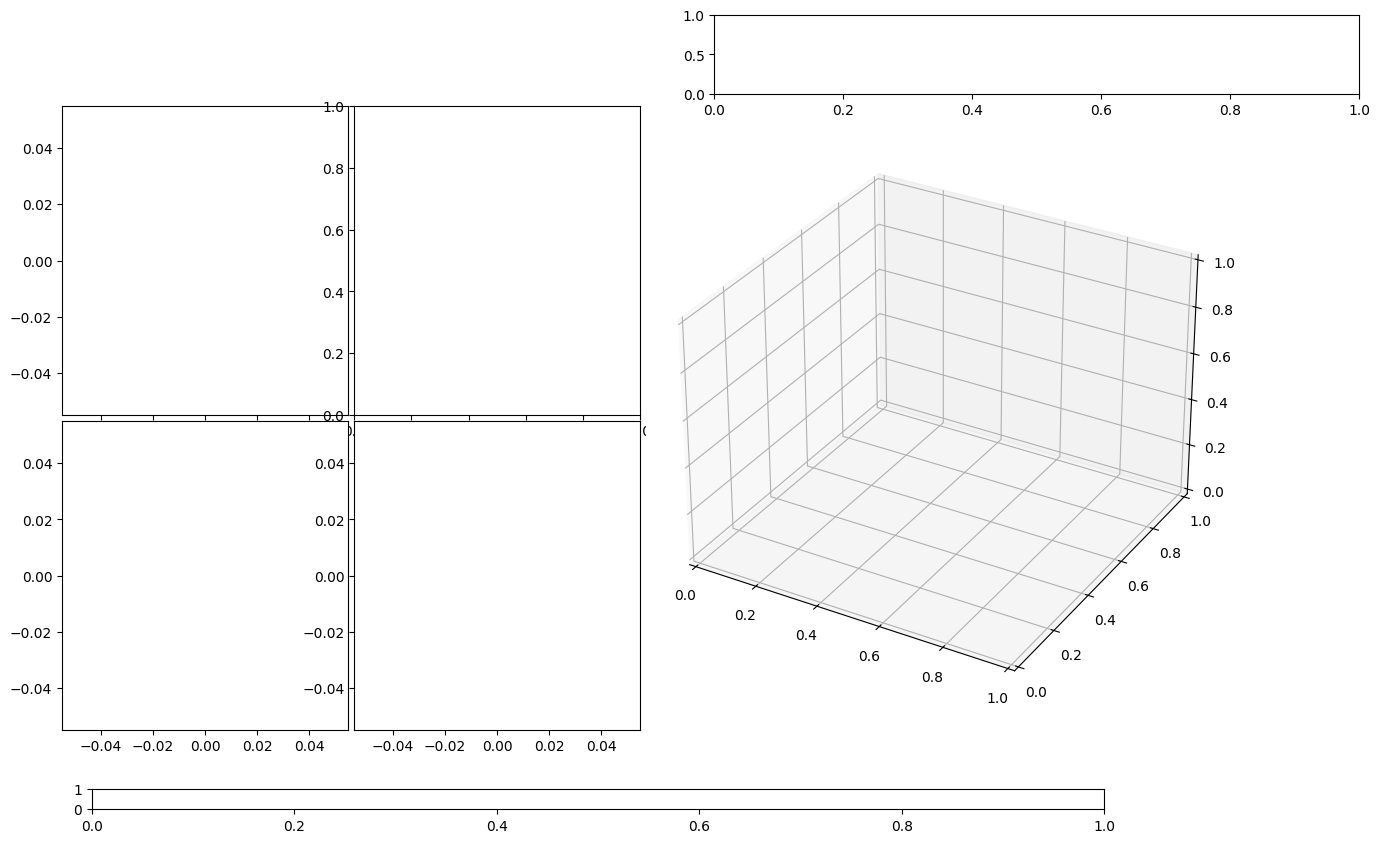

In [14]:
import sys
# Add paths for the LArEventDisplay class
sys.path.append('/home/bilal/LAr_evd/ndlar_flow/event_display/LAr_evd/')
sys.path.append('/home/bilal/LAr_evd/h5flow')
mpi4py_path = '/home/bilal/LAr_evd/ndlar_flow/ndlar_flow.venv/lib/python3.10/site-packages'
sys.path.append(mpi4py_path)

from lar2x2_evd import *
import matplotlib.pyplot as plt

plt.ion()

# File paths and event display configuration
filedir = '/home/bilal/LAr_evd/ndlar_flow/event_display/LAr_evd/'
filename = 'packet-0050017-2024_07_09_00_04_33_CDT.FLOW.hdf5'
mx2_file = None  # Optional

# Event display with specific event
evd = LArEventDisplay(
    filedir=filedir,
    filename=filename,
    nhits_min=0,  # Explicitly set for Event 190
    nhits_max=0,  # Restrict to exactly this value if needed
    ntrigs=0,       # External triggers requirement
    show_light=False,
    show_colorbars=True,
    filepath_mx2=mx2_file
)

# Run the event display
evd.run()